# Tu modelo en la web: plantilla

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel01010101010101/Ejercicio_ejemplo_machine_learning/blob/main/notebooks/plantilla_tu_modelo.ipynb)

Con este cuaderno conviertes **tus datos** (un archivo CSV) en un modelo que funciona en una página web, como el [Predictor Saber 11](https://daniel01010101010101.github.io/Ejercicio_ejemplo_machine_learning/).

**Solo haces tres cosas:**

1. Llena el formulario **«1. Configura tu modelo»**: el nombre de tu página, tus datos, qué quieres predecir y qué modelo usar.
2. Menú **Entorno de ejecución → Ejecutar todas** (en inglés: *Runtime → Run all*).
3. Sube el archivo `modelo.js` que se descarga al final a la carpeta `web` de tu repositorio en GitHub.

Si no cambias nada, el cuaderno usa un ejemplo (precios de diamantes) para que veas el recorrido completo.

**Tu CSV necesita:** una fila por caso, la columna que quieres predecir (un número, o una clase como «sí» o «no») y de 3 a 10 columnas que la expliquen. No uses datos personales (nombres, documentos, correos) ni columnas como género o etnia para predecir: tu página será pública.

## 1. Configura tu modelo

Escribe en el formulario de la celda de abajo. Los nombres de las columnas deben ser **exactamente** los de tu CSV (mayúsculas, tildes y espacios incluidos).

**¿Qué modelo elijo?** El cuaderno entrena los cuatro y te muestra cuál se equivoca menos. En la página se publica el que elijas en `MODELO`.

| `MODELO` | Qué es, en una frase |
|---|---|
| `boosting` (recomendado) | **Gradient Boosting**: muchos árboles pequeños en fila; cada uno corrige los errores de los anteriores. Suele ser el más preciso. |
| `bosque` | **Bosque aleatorio**: muchos árboles distintos; la estimación es el promedio de todos. |
| `arbol` | **Árbol de decisión**: un solo diagrama de preguntas de sí o no. Fácil de explicar, pero menos preciso. |
| `lineal` | **Regresión lineal**: una suma de puntos por cada respuesta. |

In [1]:
#@title 1. Configura tu modelo { display-mode: "form" }

#@markdown **Tu página**
TITULO = "Predictor de precio de diamantes"  #@param {type:"string"}
PREGUNTA = "¿Cuánto vale un diamante?"  #@param {type:"string"}
AUTOR = "Tu nombre"  #@param {type:"string"}
USUARIO_GITHUB = ""  #@param {type:"string"}

#@markdown **Tus datos**: pega el enlace a tu CSV, o déjalo vacío para subir el archivo desde tu computador.
URL_DATOS = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"  #@param {type:"string"}
NOMBRE_DATOS = "Diamonds (seaborn-data)"  #@param {type:"string"}

#@markdown **Qué quieres predecir**: el nombre exacto de la columna.
OBJETIVO = "price"  #@param {type:"string"}
ETIQUETA_OBJETIVO = "Precio"  #@param {type:"string"}
UNIDAD = "USD"  #@param {type:"string"}
#@markdown Solo si predices una clase (por ejemplo «Aprobado» o «Reprobado»): la clase cuya probabilidad quieres estimar.
CLASE_POSITIVA = ""  #@param {type:"string"}

#@markdown **Con qué lo predices**: columnas separadas por comas (vacío = el cuaderno las elige).
VARIABLES = "carat, cut, color, clarity"  #@param {type:"string"}
EXCLUIR = ""  #@param {type:"string"}

#@markdown **Qué modelo publicas**
MODELO = "boosting"  #@param ["boosting", "bosque", "arbol", "lineal"]

In [2]:
#@title 2. Opcional: textos más claros para el formulario
# Si cambiaste de datos, cambia o borra estos ejemplos (pueden quedar vacíos: {}).
ETIQUETAS = {                 # columna -> pregunta del formulario
    "carat": "Peso en quilates",
    "cut": "Calidad del corte",
    "color": "Color (D es el mejor, J el peor)",
    "clarity": "Pureza",
}
ETIQUETAS_CATEGORIAS = {      # columna -> {valor en los datos: texto en el formulario}
    "cut": {"Fair": "Regular", "Good": "Bueno", "Very Good": "Muy bueno", "Premium": "Premium", "Ideal": "Ideal"},
}
ORDEN_CATEGORIAS = {          # columna -> orden de las opciones
    "cut": ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "clarity": ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}
AVISO = "Es una estimación con error: úsala para aprender y discutir, no para tomar decisiones importantes."
CURSO = "Machine Learning 1 · Universidad EAN"

## 3. Carga los datos

Si pusiste un enlace, se descarga solo. Si lo dejaste vacío, aparece un botón para elegir tu archivo. El cuaderno reconoce CSV separados por coma o por punto y coma.

In [3]:
import datetime as dt
import io
import json
import math
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

EN_COLAB = "google.colab" in sys.modules
SIN_INFO = "Sin información"
OTRA = "Otra (pocos casos)"
SEMILLA = 42
CARPETA_SALIDA = Path("mi_modelo")
NOMBRES = {
    "lineal": "Regresión lineal (Ridge)",
    "arbol": "Árbol de decisión",
    "bosque": "Bosque aleatorio (50 árboles)",
    "boosting": "Gradient Boosting",
}


def fmt(numero, decimales=0):
    """Formato colombiano: 12.345,6"""
    texto = f"{numero:,.{decimales}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


def columnas_de(texto):
    """'a, b, c' -> ['a', 'b', 'c'] (también acepta una lista)."""
    if isinstance(texto, (list, tuple)):
        return [str(c) for c in texto]
    return [c.strip() for c in str(texto or "").split(",") if c.strip()]


def leer_csv(fuente):
    """Lee un CSV separado por comas o por punto y coma, en UTF-8 o Latin-1."""
    for codificacion in ("utf-8", "latin-1"):
        try:
            origen = io.BytesIO(fuente) if isinstance(fuente, bytes) else fuente
            return pd.read_csv(origen, sep=None, engine="python", encoding=codificacion)
        except UnicodeDecodeError:
            continue
    raise ValueError("No pude leer el archivo. Guárdalo como «CSV UTF-8» y vuelve a intentar.")


VARIABLES = columnas_de(VARIABLES) or None
EXCLUIR = columnas_de(EXCLUIR)
MODELO = str(MODELO).strip().lower()
if MODELO not in NOMBRES:
    raise ValueError(f"MODELO debe ser uno de {list(NOMBRES)}; escribiste {MODELO!r}.")

if URL_DATOS.strip():
    datos = leer_csv(URL_DATOS.strip())
else:
    from google.colab import files
    print("Elige tu archivo CSV (botón «Elegir archivos»):")
    subido = files.upload()
    datos = leer_csv(next(iter(subido.values())))
datos.columns = [str(c).strip() for c in datos.columns]
print(f"Tus datos tienen {fmt(len(datos))} filas y {datos.shape[1]} columnas:")
print(", ".join(datos.columns))
datos.head()

Tus datos tienen 53.940 filas y 10 columnas:
carat, cut, color, clarity, depth, table, price, x, y, z


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 4. Revisa tus datos y lo que quieres predecir

La tabla muestra cada columna: si es número o texto, cuántos vacíos tiene y cuántos valores distintos.

- Si lo que predices es un **número** (un precio, un puntaje), el modelo estima ese número.
- Si es **sí o no** (0 y 1) o una **clase** (por ejemplo «Aprobado»), el modelo estima la **probabilidad** de 0 a 100 %.

In [4]:
def a_numero(serie):
    """Convierte a número; acepta coma decimal (3,5)."""
    return pd.to_numeric(serie.astype(str).str.replace(",", ".", regex=False), errors="coerce")


def es_numerica(serie):
    return a_numero(serie).notna().mean() >= 0.95 * serie.notna().mean()


resumen = pd.DataFrame({
    "tipo": ["número" if es_numerica(datos[c]) else "texto" for c in datos.columns],
    "% vacíos": (100 * datos.isna().mean()).round(1).values,
    "valores distintos": datos.nunique().values,
    "ejemplo": [datos[c].dropna().iloc[0] if datos[c].notna().any() else "" for c in datos.columns],
}, index=datos.columns)
display(resumen)

if OBJETIVO not in datos.columns:
    raise ValueError(f"No encuentro la columna OBJETIVO = {OBJETIVO!r}. Copia el nombre exacto de la tabla de arriba.")
objetivo = datos[OBJETIVO]
CLASE_POSITIVA = str(CLASE_POSITIVA).strip()
ES_PROBABILIDAD = False
if es_numerica(objetivo) and not CLASE_POSITIVA:
    y_todo = a_numero(objetivo)
    if set(y_todo.dropna().unique()) <= {0, 1}:
        ES_PROBABILIDAD, CLASE_POSITIVA = True, "1"
        y_todo = 100 * y_todo
else:
    # El objetivo es una clase: se estima la probabilidad de CLASE_POSITIVA.
    texto = objetivo.astype("string").str.strip()
    clases = texto.value_counts()
    if not CLASE_POSITIVA:
        if len(clases) != 2:
            raise ValueError(f"Tu objetivo tiene {len(clases)} clases ({', '.join(map(str, clases.index[:8]))}). "
                             "Escribe en CLASE_POSITIVA la clase cuya probabilidad quieres estimar.")
        CLASE_POSITIVA = str(clases.index[-1])  # la menos frecuente
    if CLASE_POSITIVA not in set(clases.index.astype(str)):
        raise ValueError(f"No encuentro la clase {CLASE_POSITIVA!r} en {OBJETIVO!r}. Clases: {', '.join(map(str, clases.index[:8]))}.")
    ES_PROBABILIDAD = True
    y_todo = (100.0 * (texto == CLASE_POSITIVA)).where(texto.notna()).astype(float)
if y_todo.notna().mean() < 0.5:
    raise ValueError(f"La columna {OBJETIVO!r} no es numérica. Elige una columna de números, o una clase con CLASE_POSITIVA.")
if ES_PROBABILIDAD:
    UNIDAD = "%"
    if ETIQUETA_OBJETIVO.strip() in ("", "Precio"):
        ETIQUETA_OBJETIVO = (f"Probabilidad de {OBJETIVO} = 1" if CLASE_POSITIVA == "1"
                             else f"Probabilidad de «{CLASE_POSITIVA}»")
    print(f"Tu objetivo es una clase: el modelo estimará la probabilidad (de 0 a 100 %) de «{CLASE_POSITIVA}».")
print(f"Objetivo «{OBJETIVO}»: promedio {fmt(y_todo.mean(), 1)} · mínimo {fmt(y_todo.min(), 1)} · "
      f"máximo {fmt(y_todo.max(), 1)} · vacíos {fmt(y_todo.isna().sum())}")

,tipo,% vacíos,valores distintos,ejemplo
carat,número,0.0,273,0.23
cut,texto,0.0,5,Ideal
color,texto,0.0,7,E
clarity,texto,0.0,8,SI2
depth,número,0.0,184,61.5
table,número,0.0,127,55.0
price,número,0.0,11602,326
x,número,0.0,554,3.95
y,número,0.0,552,3.98
z,número,0.0,375,2.43


Objetivo «price»: promedio 3.932,8 · mínimo 326,0 · máximo 18.823,0 · vacíos 0


## 5. Separa entrenamiento y prueba

El 80 % de las filas es para **entrenar** y el 20 % para **evaluar** con casos que el modelo nunca vio, como un examen con preguntas nuevas. Se separa **antes** de aprender cualquier cosa de los datos.

In [5]:
filas_validas = y_todo.notna()
x_todo = datos.loc[filas_validas].drop(columns=[OBJETIVO])
y_todo = y_todo[filas_validas]
x_train, x_test, y_train, y_test = train_test_split(x_todo, y_todo, test_size=0.2, random_state=SEMILLA)
MIN_CASOS = max(20, round(0.005 * len(x_train)))
print(f"Entrenamiento: {fmt(len(x_train))} filas · Prueba: {fmt(len(x_test))} filas")
print(f"Una categoría con menos de {MIN_CASOS} casos en entrenamiento se agrupa en «{OTRA}».")

Entrenamiento: 43.152 filas · Prueba: 10.788 filas
Una categoría con menos de 216 casos en entrenamiento se agrupa en «Otra (pocos casos)».


## 6. Prepara las columnas

Todo se aprende **solo con entrenamiento** y se aplica igual a la prueba:

- Una columna de **texto** conserva sus categorías; las que tienen muy pocos casos se agrupan y los vacíos pasan a «Sin información». En la página será una lista de opciones.
- Una columna de **números** queda como número (en la página, una barra para elegir el valor). Los vacíos se llenan con la mediana. Solo la regresión lineal la parte en 5 rangos.

In [6]:
def como_texto(serie):
    """Texto limpio de una columna; los números se escriben sin decimales de sobra."""
    if es_numerica(serie):
        numeros = a_numero(serie)
        texto = numeros.map(lambda v: "" if pd.isna(v) else fmt(v, 0 if float(v).is_integer() else 2))
    else:
        texto = serie.astype("string").str.strip()
    return texto.fillna(SIN_INFO).replace("", SIN_INFO).astype(object)


def aprender_preparacion(train, columna):
    """Aprende, SOLO con train, cómo usar una columna: como número o como categorías."""
    serie = train[columna]
    if es_numerica(serie) and serie.nunique() > 10:
        valores = a_numero(serie).dropna()
        cortes = sorted(set(float(c) for c in np.quantile(valores, [0.2, 0.4, 0.6, 0.8]).round(6)))
        return {"tipo": "numero", "cortes": cortes, "decimales": 0 if all(c.is_integer() for c in cortes) else 2}
    conteo = como_texto(serie).value_counts()
    return {"tipo": "categorias", "frecuentes": list(conteo[conteo >= MIN_CASOS].index[:29])}


def etiquetas_rangos(prep):
    c, d = prep["cortes"], prep["decimales"]
    if not c:
        return ["Todos"]
    return ([f"hasta {fmt(c[0], d)}"] + [f"{fmt(a, d)} a {fmt(b, d)}" for a, b in zip(c[:-1], c[1:])]
            + [f"más de {fmt(c[-1], d)}"])


def aplicar_preparacion(tabla, columna, prep, en_rangos=False):
    """Una columna lista para el modelo. en_rangos=True: los números como rangos (regresión lineal)."""
    if prep["tipo"] == "numero" and not en_rangos:
        return a_numero(tabla[columna])
    if prep["tipo"] == "numero":
        bordes = [-np.inf] + prep["cortes"] + [np.inf]
        rangos = pd.cut(a_numero(tabla[columna]), bins=bordes, labels=etiquetas_rangos(prep))
        return rangos.astype(object).where(rangos.notna(), SIN_INFO)
    texto = como_texto(tabla[columna])
    return texto.where(texto.isin(prep["frecuentes"]), OTRA)


if VARIABLES is None:
    # El cuaderno propone las columnas que más explican el objetivo por sí solas (medido en train).
    puntajes = {}
    for columna in [c for c in x_train.columns if c not in EXCLUIR]:
        categoria = aplicar_preparacion(x_train, columna, aprender_preparacion(x_train, columna), en_rangos=True)
        if categoria.nunique() < 2:
            continue
        medias = y_train.groupby(categoria).transform("mean")
        puntaje = 1 - ((y_train - medias) ** 2).sum() / ((y_train - y_train.mean()) ** 2).sum()
        if puntaje > 0.98:
            # Casi idéntica al objetivo: seguramente es otra forma de la respuesta (una «fuga»).
            print(f"Se deja por fuera «{columna}»: explica casi todo el objetivo por sí sola. ¿Es otra forma de la respuesta?")
            continue
        puntajes[columna] = puntaje
    VARIABLES = [c for c, _ in sorted(puntajes.items(), key=lambda par: -par[1])[:8]]
    print("El cuaderno eligió estas columnas:", ", ".join(VARIABLES))

faltan = [c for c in VARIABLES if c not in x_train.columns]
if faltan:
    raise ValueError(f"Estas columnas de VARIABLES no existen en tus datos: {faltan}")
if any(c in EXCLUIR for c in VARIABLES):
    raise ValueError("Una columna está a la vez en VARIABLES y en EXCLUIR.")
if OBJETIVO in VARIABLES:
    raise ValueError("La columna OBJETIVO no puede estar también en VARIABLES.")

preparacion = {c: aprender_preparacion(x_train, c) for c in VARIABLES}   # SOLO con train
CATEGORICAS = [c for c in VARIABLES if preparacion[c]["tipo"] == "categorias"]
NUMERICAS = [c for c in VARIABLES if preparacion[c]["tipo"] == "numero"]


def preparar(tabla, en_rangos=False):
    return pd.DataFrame({c: aplicar_preparacion(tabla, c, preparacion[c], en_rangos) for c in VARIABLES}, index=tabla.index)


x_train_arb, x_test_arb = preparar(x_train), preparar(x_test)                               # para los árboles
x_train_lin, x_test_lin = preparar(x_train, en_rangos=True), preparar(x_test, en_rangos=True)  # para la lineal
for c in VARIABLES:
    detalle = "número" if c in NUMERICAS else f"{x_train_arb[c].nunique()} categorías"
    print(f"  {ETIQUETAS.get(c, c)} ({c}): {detalle}")

  Peso en quilates (carat): número
  Calidad del corte (cut): 5 categorías
  Color (D es el mejor, J el peor) (color): 7 categorías
  Pureza (clarity): 8 categorías


## 7. Entrena cuatro modelos y compáralos

Los cuatro aprenden con el mismo entrenamiento y se evalúan con la misma prueba. La **línea base** responde siempre el promedio: un modelo vale la pena en la medida en que le gana.

- **MAE**: en promedio, ¿por cuánto se equivoca? En la unidad de lo que predices. **Menos es mejor.**
- **R²**: qué parte de las diferencias entre casos explica el modelo (0 = igual que adivinar el promedio; 1 = perfecto).
- **Exactitud** (solo si predices una clase): de cada 100 casos de prueba, cuántos acierta si decimos «sí» cuando la probabilidad pasa del 50 %.

In [7]:
def metricas(y_real, y_pred) -> dict:
    return {
        "mae": float(mean_absolute_error(y_real, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_real, y_pred))),
        "r2": float(r2_score(y_real, y_pred)),
    }


def crear_modelo(tipo):
    """Un Pipeline: prepara las columnas y después el modelo elegido."""
    if tipo == "lineal":
        columnas = ColumnTransformer([("categoricas", OneHotEncoder(handle_unknown="ignore"), VARIABLES)])
        return Pipeline([("preprocesamiento", columnas), ("regresion", Ridge(alpha=1.0))])
    partes = []
    if CATEGORICAS:
        partes.append(("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS))
    if NUMERICAS:
        partes.append(("numeros", SimpleImputer(strategy="median"), NUMERICAS))
    regresor = {
        "arbol": DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=SEMILLA),
        "bosque": RandomForestRegressor(n_estimators=50, max_depth=10, min_samples_leaf=5, max_features=0.5,
                                        n_jobs=-1, random_state=SEMILLA),
        "boosting": HistGradientBoostingRegressor(random_state=SEMILLA),  # 100 árboles de hasta 31 hojas
    }[tipo]
    return Pipeline([("preprocesamiento", ColumnTransformer(partes)), ("regresion", regresor)])


def datos_para(tipo):
    return (x_train_lin, x_test_lin) if tipo == "lineal" else (x_train_arb, x_test_arb)


def evaluar(y_real, y_pred):
    fila = metricas(y_real, y_pred)
    if ES_PROBABILIDAD:
        fila["exactitud"] = float(np.mean((np.asarray(y_pred) >= 50) == (np.asarray(y_real) >= 50)))
    return fila


base = DummyRegressor(strategy="mean").fit(x_train_arb, y_train)
comparacion = [{"clave": "linea_base", "nombre": "Línea base: siempre el promedio", **evaluar(y_test, base.predict(x_test_arb))}]
modelos = {}
for tipo in NOMBRES:
    entrenamiento, prueba = datos_para(tipo)
    modelos[tipo] = crear_modelo(tipo).fit(entrenamiento, y_train)
    fila = {"clave": tipo, "nombre": NOMBRES[tipo], **evaluar(y_test, modelos[tipo].predict(prueba))}
    if tipo == MODELO:
        fila["publicado"] = True
    comparacion.append(fila)

tabla = pd.DataFrame(comparacion).set_index("nombre")
columnas = ["mae", "rmse", "r2"] + (["exactitud"] if ES_PROBABILIDAD else [])
tabla = tabla[columnas].rename(columns={"mae": "MAE", "rmse": "RMSE", "r2": "R²", "exactitud": "Exactitud"})
tabla["Se publica"] = ["sí" if f.get("publicado") else "" for f in comparacion]
display(tabla.round(3))

publicado = next(f for f in comparacion if f.get("publicado"))
# Con una clase gana el que más acierta; con un número, el que menos se equivoca.
mejor = (max(comparacion[1:], key=lambda f: f["exactitud"]) if ES_PROBABILIDAD
         else min(comparacion[1:], key=lambda f: f["mae"]))
mejora = 1 - publicado["mae"] / comparacion[0]["mae"]
print(f"Tu modelo ({NOMBRES[MODELO]}) se equivoca en promedio {fmt(publicado['mae'], 1)} {UNIDAD}; "
      f"la línea base, {fmt(comparacion[0]['mae'], 1)} {UNIDAD}. Mejora: {fmt(100 * mejora)} %.")
if ES_PROBABILIDAD:
    print(f"Exactitud de tu modelo: acierta {fmt(100 * publicado['exactitud'])} de cada 100 casos de prueba "
          f"(la línea base, {fmt(100 * comparacion[0]['exactitud'])}).")
if mejor is not publicado:
    criterio = (f"el que más acierta es {mejor['nombre']} ({fmt(100 * mejor['exactitud'])} de cada 100)" if ES_PROBABILIDAD
                else f"el que menos se equivoca es {mejor['nombre']} (MAE {fmt(mejor['mae'], 1)})")
    print(f"En la prueba, {criterio}. Si quieres publicarlo, elige MODELO = \"{mejor['clave']}\" y vuelve a ejecutar todo.")
if mejora < 0.05:
    print("Ojo: casi no le gana a la línea base. Prueba con otras columnas en VARIABLES.")
if publicado["r2"] > 0.99:
    print("Ojo: el modelo acierta casi perfecto. Revisa que ninguna columna de VARIABLES sea otra forma del objetivo.")

,MAE,RMSE,R²,Se publica
nombre,,,,
Línea base: siempre el promedio,3020.506,3987.222,-0.000,
Regresión lineal (Ridge),1103.029,1857.524,0.783,
Árbol de decisión,588.402,1085.271,0.926,
Bosque aleatorio (50 árboles),387.565,700.824,0.969,
Gradient Boosting,294.945,567.011,0.980,sí


Tu modelo (Gradient Boosting) se equivoca en promedio 294,9 USD; la línea base, 3.020,5 USD. Mejora: 90 %.


## 8. ¿Qué pesa más en tu modelo?

Para cada caso, el modelo parte del promedio y cada respuesta sube o baja la estimación. La gráfica muestra cuánto mueve, en promedio, cada columna. Son **asociaciones, no causas**.

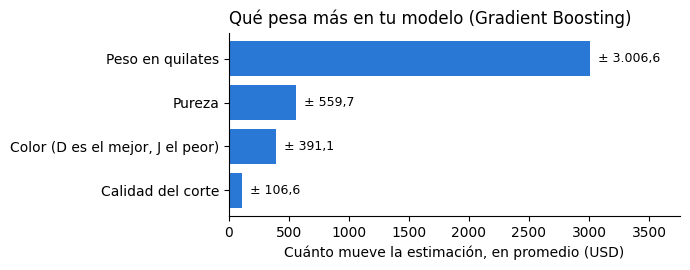

In [8]:
def arboles_de(regresor) -> dict:
    """Los árboles de un modelo de scikit-learn como listas de números (lo que lee web/motor.js).

    Por cada nodo: la columna por la que pregunta (c; -1 en las hojas), el umbral (u),
    el hijo si columna <= umbral (i), el hijo si no (d) y el valor del nodo (v).
    estimación = base + escala x (suma de las hojas a las que llega cada árbol).
    modo: "suma" (Gradient Boosting), "promedio" (bosque aleatorio) o "arbol" (uno solo).
    """
    def entero(a):
        return np.asarray(a).astype(np.int64)  # algunos índices vienen sin signo (uint32)

    def arbol(columna, umbral, izquierda, derecha, valor):
        hoja = entero(izquierda) < 0
        return {"c": np.where(hoja, -1, entero(columna)).tolist(),
                "u": np.where(hoja, 0.0, np.asarray(umbral, dtype=float)).tolist(),
                "i": np.where(hoja, -1, entero(izquierda)).tolist(),
                "d": np.where(hoja, -1, entero(derecha)).tolist(),
                "v": np.asarray(valor, dtype=float).tolist()}

    if isinstance(regresor, HistGradientBoostingRegressor):
        # scikit-learn guarda estos árboles en _predictors, un atributo interno. Si una
        # versión futura lo cambia, este paso falla (o falla la prueba de paridad).
        lista = []
        for (predictor,) in regresor._predictors:
            nodos = predictor.nodes
            if nodos["is_categorical"].any():
                raise ValueError("Se esperaban solo columnas numéricas o one-hot")
            hoja = nodos["is_leaf"].astype(bool)
            izquierda = np.where(hoja, -1, entero(nodos["left"]))
            derecha = np.where(hoja, -1, entero(nodos["right"]))
            # Las hojas ya traen la tasa de aprendizaje. Cada nodo interno recibe el promedio
            # de sus dos hijos, ponderado por casos: con eso se reparten los aportes.
            valor = nodos["value"].astype(float)
            for n in range(len(nodos) - 1, -1, -1):
                if not hoja[n]:
                    i, d = izquierda[n], derecha[n]
                    if min(i, d) <= n:
                        raise ValueError("Orden de nodos inesperado en el árbol")
                    casos_i, casos_d = float(nodos["count"][i]), float(nodos["count"][d])
                    valor[n] = (casos_i * valor[i] + casos_d * valor[d]) / (casos_i + casos_d)
            lista.append(arbol(nodos["feature_idx"], nodos["num_threshold"], izquierda, derecha, valor))
        return {"modo": "suma", "base": float(np.ravel(regresor._baseline_prediction)[0]),
                "escala": 1.0, "float32": False, "lista": lista}
    if isinstance(regresor, RandomForestRegressor):
        arboles, escala, modo = [e.tree_ for e in regresor.estimators_], 1.0 / len(regresor.estimators_), "promedio"
    elif isinstance(regresor, DecisionTreeRegressor):
        arboles, escala, modo = [regresor.tree_], 1.0, "arbol"
    else:
        raise TypeError(f"No sé exportar {type(regresor).__name__}")
    # Estos árboles de scikit-learn comparan en float32; motor.js hace lo mismo.
    return {"modo": modo, "base": 0.0, "escala": escala, "float32": True,
            "lista": [arbol(a.feature, a.threshold, a.children_left, a.children_right, a.value[:, 0, 0])
                      for a in arboles]}


def recorrer_arboles(arboles: dict, x, variable_de_columna, n_variables: int):
    """Hace en Python lo mismo que web/motor.js, para muchas filas a la vez.

    Devuelve la estimación, el punto de partida y el aporte de cada variable: cuánto
    cambió el valor del nodo en los pasos del camino que preguntaron por ella.
    """
    x = np.asarray(x, dtype=float)
    if arboles["float32"]:
        x = x.astype(np.float32).astype(float)
    variable_de_columna = np.asarray(variable_de_columna)
    filas = np.arange(len(x))
    escala = arboles["escala"]
    estimacion = np.full(len(x), arboles["base"])
    partida = arboles["base"]
    aportes = np.zeros((len(x), n_variables))
    for arbol in arboles["lista"]:
        c, u, i, d, v = (np.asarray(arbol[k]) for k in ("c", "u", "i", "d", "v"))
        partida += escala * v[0]
        nodo = np.zeros(len(x), dtype=int)
        activas = c[nodo] >= 0
        while activas.any():
            f, n = filas[activas], nodo[activas]
            hijo = np.where(x[f, c[n]] <= u[n], i[n], d[n])
            np.add.at(aportes, (f, variable_de_columna[c[n]]), escala * (v[hijo] - v[n]))
            nodo[f] = hijo
            activas = c[nodo] >= 0
        estimacion += escala * v[nodo]
    return estimacion, partida, aportes


modelo = modelos[MODELO]
x_modelo_train, x_modelo_test = datos_para(MODELO)
preprocesamiento = modelo.named_steps["preprocesamiento"]
regresor = modelo.named_steps["regresion"]
muestra = x_modelo_train.sample(n=min(5000, len(x_modelo_train)), random_state=SEMILLA)

if MODELO == "lineal":
    codificador = preprocesamiento.named_transformers_["categoricas"]
    coeficientes, inicio = {}, 0
    for v, lista in zip(VARIABLES, codificador.categories_):
        coeficientes[v] = dict(zip(lista, regresor.coef_[inicio:inicio + len(lista)]))
        inicio += len(lista)

    def efecto_medio(v):
        frecuencia = x_modelo_train[v].value_counts(normalize=True)
        return sum(k * frecuencia.get(c, 0.0) for c, k in coeficientes[v].items())

    # Aporte de cada respuesta: su coeficiente menos el efecto promedio de esa pregunta.
    aportes = np.column_stack([muestra[v].map(coeficientes[v]).fillna(0).to_numpy() - efecto_medio(v)
                               for v in VARIABLES])
else:
    arboles = arboles_de(regresor)
    columnas_arbol = ([[v, str(c)] for v, lista in zip(CATEGORICAS, preprocesamiento.named_transformers_["categoricas"].categories_) for c in lista]
                      if CATEGORICAS else []) + [[v] for v in NUMERICAS]
    arboles["columnas"] = columnas_arbol
    variable_de_columna = [VARIABLES.index(c[0]) for c in columnas_arbol]
    estimacion, _, aportes = recorrer_arboles(arboles, preprocesamiento.transform(muestra), variable_de_columna, len(VARIABLES))
    diferencia = float(np.max(np.abs(estimacion - modelo.predict(muestra))))
    assert diferencia <= 1e-6, f"Los árboles exportados no reproducen a scikit-learn (diferencia {diferencia})"

importancia = pd.Series(np.abs(aportes).mean(axis=0), index=[ETIQUETAS.get(v, v) for v in VARIABLES]).sort_values()
fig, ax = plt.subplots(figsize=(7, 0.45 * len(importancia) + 1))
ax.barh(importancia.index, importancia.values, color="#2a78d6")
for i, valor in enumerate(importancia.values):
    ax.text(valor, i, f"  ± {fmt(valor, 1)}", va="center", fontsize=9)
ax.set_xlabel(f"Cuánto mueve la estimación, en promedio ({UNIDAD})")
ax.set_title(f"Qué pesa más en tu modelo ({NOMBRES[MODELO]})", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, importancia.max() * 1.25)
plt.tight_layout()
plt.show()

## 9. Exporta `modelo.js` y verifica

Guardamos el modelo como **números** dentro de `modelo.js`: para los árboles, cada pregunta de sí o no y el número de cada hoja; para la regresión lineal, un número por respuesta. Van junto con los textos de tu página.

Después, una **prueba de paridad** recalcula las predicciones con el mismo JavaScript de la página (`motor.js`) y exige que den lo mismo que scikit-learn (tolerancia 1e-6). Si no coinciden, no subas el archivo.

In [9]:
def a_json(modelo_dict: dict) -> str:
    """JSON legible, pero con los árboles en una sola línea (son miles de números)."""
    if "arboles" not in modelo_dict:
        return json.dumps(modelo_dict, ensure_ascii=False, indent=2)
    marcador = "__ARBOLES__"
    texto = json.dumps({**modelo_dict, "arboles": marcador}, ensure_ascii=False, indent=2)
    return texto.replace(f'"{marcador}"', json.dumps(modelo_dict["arboles"], separators=(",", ":")))


def etiqueta_de(v, valor):
    return str(ETIQUETAS_CATEGORIAS.get(v, {}).get(valor, valor))


def orden_de(v, valor):
    """Orden de las opciones: el de ORDEN_CATEGORIAS, los rangos de menor a mayor, y al final los vacíos."""
    if valor == SIN_INFO:
        return (2, 0, "")
    if valor == OTRA:
        return (3, 0, "")
    if preparacion[v]["tipo"] == "numero":
        return (0, etiquetas_rangos(preparacion[v]).index(valor), "")
    orden = [str(o) for o in ORDEN_CATEGORIAS.get(v, [])]
    if valor in orden:
        return (0, orden.index(valor), "")
    numero = pd.to_numeric(valor.replace(".", "").replace(",", "."), errors="coerce")
    return (1, float(numero) if pd.notna(numero) else math.inf, valor.lower())


def paso_redondo(valor):
    p = 10 ** math.floor(math.log10(valor))
    return next(m * p for m in (1, 2, 2.5, 5, 10) if valor <= m * p)


if ES_PROBABILIDAD:
    minimo, maximo = 0.0, 100.0
else:
    paso = paso_redondo((y_todo.max() - min(0, y_todo.min())) / 5)
    minimo = 0.0 if y_todo.min() >= 0 else math.floor(y_todo.min() / paso) * paso
    maximo = math.ceil(y_todo.max() / paso) * paso

ARBOLES = MODELO != "lineal"
categorias_de = {}
if ARBOLES and CATEGORICAS:
    categorias_de = dict(zip(CATEGORICAS, preprocesamiento.named_transformers_["categoricas"].categories_))
elif not ARBOLES:
    categorias_de = dict(zip(VARIABLES, preprocesamiento.named_transformers_["categoricas"].categories_))
medianas = (dict(zip(NUMERICAS, preprocesamiento.named_transformers_["numeros"].statistics_))
            if ARBOLES and NUMERICAS else {})

variables = []
for k, v in enumerate(VARIABLES):
    fila = {"nombre": v, "etiqueta": ETIQUETAS.get(v, v), "etiqueta_corta": ETIQUETAS.get(v, v), "grupo": "caso", "ayuda": ""}
    if v in medianas:
        numeros = x_modelo_train[v].dropna()
        enteros = bool(np.all(np.mod(numeros, 1) == 0))
        rango = float(numeros.max() - numeros.min())
        paso_barra = 1.0 if enteros or rango == 0 else 10 ** math.floor(math.log10(rango / 100))
        fila.update({"tipo": "numero", "minimo": float(numeros.min()), "maximo": float(numeros.max()),
                     "mediana": float(medianas[v]), "paso": paso_barra,
                     "decimales": 0 if enteros else max(0, -int(math.floor(math.log10(paso_barra))))})
    else:
        conteo = x_modelo_train[v].value_counts()
        opciones = []
        for c in categorias_de[v]:
            opcion = {"valor": str(c), "etiqueta": etiqueta_de(v, c)}
            if not ARBOLES:
                opcion["coeficiente"] = float(coeficientes[v][c])
            opcion.update({"frecuencia": float(conteo.get(c, 0) / len(x_modelo_train)), "n": int(conteo.get(c, 0)),
                           "en_formulario": bool(conteo.get(c, 0) >= MIN_CASOS)})
            opciones.append(opcion)
        opciones.sort(key=lambda f: orden_de(v, f["valor"]))
        fila.update({"tipo": "categoria", "mas_frecuente": str(conteo.idxmax()), "categorias": opciones})
        if not ARBOLES and preparacion[v]["tipo"] == "numero":
            fila["ayuda"] = "Elige el rango."
    fila["importancia"] = float(np.abs(aportes[:, k]).mean())
    variables.append(fila)

# 5 casos del set de prueba (estimaciones bajas, medias y altas) que el formulario puede mostrar.
visibles = pd.Series(True, index=x_modelo_test.index)
for v in VARIABLES:
    if v not in medianas:
        conteo = x_modelo_train[v].value_counts()
        visibles &= x_modelo_test[v].isin(conteo[conteo >= MIN_CASOS].index)
x_casos, y_casos = x_modelo_test[visibles], y_test[visibles]
orden = np.argsort(modelo.predict(x_casos), kind="stable")
casos = []
for numero, q in enumerate(np.linspace(0.05, 0.95, 5), start=1):
    i = int(orden[int(round(q * (len(orden) - 1)))])
    entradas = {}
    for v in VARIABLES:
        valor = x_casos.iloc[i][v]
        entradas[v] = (float(medianas[v]) if pd.isna(valor) else float(valor)) if v in medianas else str(valor)
    fila = pd.DataFrame([entradas], columns=VARIABLES)
    casos.append({"id": numero, "entradas": entradas, "puntaje_real": float(y_casos.iloc[i]),
                  "prediccion_sklearn": float(modelo.predict(fila)[0])})

prediccion_test = modelo.predict(x_modelo_test)
mae = publicado["mae"]
exportado = {
    "version": "2.0.0",
    "proyecto": TITULO,
    "fuente": {"nombre": NOMBRE_DATOS, "url": URL_DATOS.strip(), "portal": "", "id": ""},
    "fecha_entrenamiento": dt.date.today().isoformat(),
    "n_total": int(len(y_todo)), "n_entrenamiento": int(len(y_train)), "n_prueba": int(len(y_test)),
    "semilla": SEMILLA, "min_casos": MIN_CASOS,
    "sklearn_version": sklearn.__version__,
    "objetivo": {"nombre": OBJETIVO, "etiqueta": ETIQUETA_OBJETIVO, "minimo": minimo, "maximo": maximo, "unidad": UNIDAD,
                 "tipo": "probabilidad" if ES_PROBABILIDAD else "numero"},
    "metricas": {"modelo": publicado, "linea_base": comparacion[0], "comparacion": comparacion},
    "cobertura_mae": float(np.mean(np.abs(y_test.to_numpy() - prediccion_test) <= mae)),
    "promedio_nacional": float(y_todo.mean()),
    "promedio_entrenamiento": float(y_train.mean()),
    "tipo": "arboles" if ARBOLES else "lineal",
    "algoritmo": {"lineal": "Ridge (alpha = 1) con codificación one-hot",
                  "arbol": f"Árbol de decisión (DecisionTreeRegressor), profundidad {regresor.get_depth() if MODELO == 'arbol' else ''}",
                  "bosque": "Bosque aleatorio (RandomForestRegressor): 50 árboles",
                  "boosting": f"Gradient Boosting (HistGradientBoostingRegressor): {getattr(regresor, 'n_iter_', '')} árboles de hasta 31 hojas"}[MODELO],
    "algoritmo_corto": {"lineal": "Regresión lineal", "arbol": "Árbol de decisión",
                        "bosque": "Bosque aleatorio", "boosting": "Gradient Boosting"}[MODELO],
    "variables": variables,
    "excluidas": [{"nombre": c, "motivo": "La excluyó el autor del modelo."} for c in EXCLUIR],
    "casos_prueba": casos,
    "textos": {
        "titulo": TITULO, "subtitulo": CURSO, "pregunta": PREGUNTA, "aviso_etico": AVISO,
        "etiqueta_promedio": "Promedio de los datos",
        "subetiqueta_medidor": "% de probabilidad" if ES_PROBABILIDAD else UNIDAD,
        "autor": AUTOR, "autor_url": f"https://github.com/{USUARIO_GITHUB.strip()}" if USUARIO_GITHUB.strip() else "",
        "grupos": {"caso": "Datos del caso"},
    },
}
if ARBOLES:
    arboles["max_aporte"] = float(np.max(np.abs(aportes)))
    exportado["arboles"] = arboles
else:
    exportado["intercepto"] = float(regresor.intercept_)
    # Identidad que usa la gráfica de aportes: intercepto + suma(frecuencia x coeficiente) = promedio de train.
    reconstruido = exportado["intercepto"] + sum(c["frecuencia"] * c["coeficiente"] for v in variables for c in v["categorias"])
    assert abs(reconstruido - exportado["promedio_entrenamiento"]) < 1e-6

CARPETA_SALIDA.mkdir(exist_ok=True)
ruta_js = CARPETA_SALIDA / "modelo.js"
ruta_js.write_text("// Generado por el cuaderno plantilla_tu_modelo.ipynb. No lo edites a mano.\n"
                   f"window.MODELO = {a_json(exportado)};\n", encoding="utf-8")
tamano = ruta_js.stat().st_size / 1024
print(f"Listo: {ruta_js} ({fmt(tamano, 0)} KB)")
if tamano > 3000:
    print("Ojo: el archivo es grande y la página cargará lento. Prueba MODELO = \"boosting\" o menos columnas.")

Listo: mi_modelo/modelo.js (191 KB)


In [10]:
MOTOR_JS = r"""// Motor de predicción del modelo exportado en modelo.js.
//
// Lo usan la página (index.html) y la prueba de paridad (scripts/prueba_paridad.js),
// así la prueba revisa exactamente el mismo código que corre en el navegador.
//
// Dos tipos de modelo:
//  - "arboles": punto de partida + la hoja a la que llega cada árbol
//    (Gradient Boosting, bosque aleatorio o un solo árbol de decisión).
//  - "lineal" (o sin tipo, como los modelo.js de la versión 1): intercepto + la suma
//    de los coeficientes de las respuestas elegidas.
(function (global) {
  'use strict';

  function categoria(variable, valor) {
    var lista = variable.categorias || [];
    for (var i = 0; i < lista.length; i++) {
      if (lista[i].valor === valor) return lista[i];
    }
    return null;
  }

  // Datos que se calculan una sola vez por modelo.
  var memoria = typeof WeakMap === 'function' ? new WeakMap() : null;
  function preparar(modelo) {
    var listo = memoria && memoria.get(modelo);
    if (listo) return listo;
    listo = { variables: {} };
    modelo.variables.forEach(function (v) { listo.variables[v.nombre] = v; });
    if (modelo.tipo === 'arboles') {
      // Cada columna de los árboles es [variable, categoría] (un uno o un cero)
      // o [variable] (un número).
      listo.columnas = modelo.arboles.columnas.map(function (c) {
        return { variable: c[0], categoria: c.length > 1 ? c[1] : null, numerica: c.length === 1 };
      });
    } else {
      // Efecto promedio de cada pregunta en entrenamiento. Se cumple:
      // intercepto + suma(efectos promedio) = promedio de entrenamiento.
      listo.efectoMedio = {};
      modelo.variables.forEach(function (v) {
        listo.efectoMedio[v.nombre] = v.categorias.reduce(function (s, c) {
          return s + c.frecuencia * c.coeficiente;
        }, 0);
      });
    }
    if (memoria) memoria.set(modelo, listo);
    return listo;
  }

  // ---------------------------------------------------------------- Lineal
  function predecirLineal(modelo, respuestas) {
    var total = modelo.intercepto;
    modelo.variables.forEach(function (v) {
      var c = categoria(v, respuestas[v.nombre]);
      if (c) total += c.coeficiente; // categoría desconocida: aporta 0
    });
    return total;
  }

  function explicarLineal(modelo, respuestas) {
    var listo = preparar(modelo);
    var aportes = {};
    modelo.variables.forEach(function (v) {
      var c = categoria(v, respuestas[v.nombre]);
      aportes[v.nombre] = (c ? c.coeficiente : 0) - listo.efectoMedio[v.nombre];
    });
    return { estimacion: predecirLineal(modelo, respuestas), partida: modelo.promedio_entrenamiento, aportes: aportes };
  }

  // ---------------------------------------------------------------- Árboles
  // Las respuestas en el orden de columnas que vio el modelo al entrenar.
  function vector(modelo, respuestas) {
    var listo = preparar(modelo);
    var float32 = modelo.arboles.float32;
    var x = new Array(listo.columnas.length);
    for (var j = 0; j < listo.columnas.length; j++) {
      var col = listo.columnas[j];
      var valor = respuestas[col.variable];
      if (!col.numerica) {
        // One-hot: 1 si es la categoría de esta columna. Una categoría desconocida
        // queda en ceros, como OneHotEncoder(handle_unknown="ignore").
        x[j] = valor === col.categoria ? 1 : 0;
        continue;
      }
      var numero = typeof valor === 'number' ? valor : parseFloat(valor);
      // Un vacío se reemplaza por la mediana de entrenamiento, como SimpleImputer.
      if (!isFinite(numero)) numero = listo.variables[col.variable].mediana;
      // Los árboles de scikit-learn comparan en float32; el Gradient Boosting, en float64.
      x[j] = float32 ? Math.fround(numero) : numero;
    }
    return x;
  }

  // Recorre cada árbol desde la raíz hasta una hoja: en cada nodo pregunta
  // «¿columna <= umbral?» y baja a la izquierda (sí) o a la derecha (no).
  // El aporte de cada respuesta es cuánto cambió el valor del nodo en los pasos
  // que preguntaron por ella; punto de partida + aportes = estimación.
  function explicarArboles(modelo, respuestas, conAportes) {
    var A = modelo.arboles;
    var listo = preparar(modelo);
    var x = vector(modelo, respuestas);
    var total = A.base, partida = A.base, aportes = {};
    if (conAportes) modelo.variables.forEach(function (v) { aportes[v.nombre] = 0; });
    for (var t = 0; t < A.lista.length; t++) {
      var arbol = A.lista[t];
      var n = 0;
      if (conAportes) partida += A.escala * arbol.v[0];
      while (arbol.c[n] >= 0) {
        var j = arbol.c[n];
        var hijo = x[j] <= arbol.u[n] ? arbol.i[n] : arbol.d[n];
        if (conAportes) aportes[listo.columnas[j].variable] += A.escala * (arbol.v[hijo] - arbol.v[n]);
        n = hijo;
      }
      total += A.escala * arbol.v[n];
    }
    return { estimacion: total, partida: partida, aportes: aportes };
  }

  // Las preguntas que hace un árbol con estas respuestas, para mostrarlas en la página.
  function recorrido(modelo, respuestas, indice) {
    var A = modelo.arboles;
    var listo = preparar(modelo);
    var arbol = A.lista[indice || 0];
    var x = vector(modelo, respuestas);
    var pasos = [];
    var n = 0;
    while (arbol.c[n] >= 0) {
      var j = arbol.c[n];
      var cumple = x[j] <= arbol.u[n];
      pasos.push({ columna: listo.columnas[j], umbral: arbol.u[n], cumple: cumple });
      n = cumple ? arbol.i[n] : arbol.d[n];
    }
    return { pasos: pasos, hoja: arbol.v[n] };
  }

  // ---------------------------------------------------------------- Uso público
  function predecir(modelo, respuestas) {
    return modelo.tipo === 'arboles'
      ? explicarArboles(modelo, respuestas, false).estimacion
      : predecirLineal(modelo, respuestas);
  }

  function explicar(modelo, respuestas) {
    return modelo.tipo === 'arboles'
      ? explicarArboles(modelo, respuestas, true)
      : explicarLineal(modelo, respuestas);
  }

  global.MotorModelo = { predecir: predecir, explicar: explicar, recorrido: recorrido, categoria: categoria };
})(typeof window !== 'undefined' ? window : this);
"""

PRUEBA_PARIDAD_JS = r"""#!/usr/bin/env node
/*
 * Prueba de paridad: la predicción en JavaScript debe coincidir con scikit-learn.
 *
 * Uso:  node scripts/prueba_paridad.js [web/modelo.js] [casos_extra.json]
 *
 * 1. Carga modelo.js y motor.js igual que el navegador. motor.js es el código que
 *    usa la página para predecir; se busca en la misma carpeta que modelo.js.
 * 2. Recalcula cada caso de prueba con ese motor.
 * 3. Compara con la predicción de scikit-learn guardada al exportar.
 * 4. Revisa que los aportes de la gráfica sumen la estimación.
 *
 * Termina con código 1 si alguna diferencia supera la tolerancia (1e-6).
 */
'use strict';

var fs = require('fs');
var path = require('path');
var vm = require('vm');

var TOLERANCIA = 1e-6;
var rutaModelo = process.argv[2] || path.join(__dirname, '..', 'web', 'modelo.js');
var rutaExtra = process.argv[3];

function rutaMotor() {
  var junto = path.join(path.dirname(rutaModelo), 'motor.js');
  if (fs.existsSync(junto)) return junto;
  return path.join(__dirname, '..', 'web', 'motor.js');
}

// Un contexto como el del navegador: los dos archivos escriben en window.
var contexto = { window: {} };
vm.createContext(contexto);
[rutaMotor(), rutaModelo].forEach(function (ruta) {
  vm.runInContext(fs.readFileSync(ruta, 'utf8'), contexto, { filename: ruta });
});
var motor = contexto.window.MotorModelo;
var modelo = contexto.window.MODELO;
if (!motor) throw new Error('motor.js no definió window.MotorModelo');
if (!modelo) throw new Error(rutaModelo + ' no definió window.MODELO');

function desconocidas(caso) {
  // Respuestas de texto que no están entre las categorías del modelo.
  return modelo.variables.filter(function (v) {
    return v.tipo !== 'numero' && !motor.categoria(v, caso.entradas[v.nombre]);
  }).length;
}

function comparar(casos) {
  var resumen = { n: casos.length, maxDif: 0, fallos: 0, desconocidas: 0 };
  casos.forEach(function (caso) {
    resumen.desconocidas += desconocidas(caso);
    var dif = Math.abs(motor.predecir(modelo, caso.entradas) - caso.prediccion_sklearn);
    if (dif > resumen.maxDif) resumen.maxDif = dif;
    if (!(dif <= TOLERANCIA)) resumen.fallos += 1;
  });
  return resumen;
}

function formato(numero) {
  return numero.toFixed(6).padStart(12);
}

var ok = true;
var tipo = modelo.tipo === 'arboles' ? modelo.arboles.lista.length + ' árboles' : 'lineal';
console.log('Modelo ' + modelo.version + (modelo.periodo ? ' · periodo ' + modelo.periodo : '') +
            ' · ' + tipo + ' · ' + modelo.variables.length + ' variables');
console.log('Caso       sklearn   JavaScript    diferencia');
modelo.casos_prueba.forEach(function (caso) {
  var js = motor.predecir(modelo, caso.entradas);
  var dif = Math.abs(js - caso.prediccion_sklearn);
  console.log(String(caso.id).padStart(4) + ' ' + formato(caso.prediccion_sklearn) + ' ' +
              formato(js) + '  ' + dif.toExponential(2));
});

var casos = comparar(modelo.casos_prueba);
console.log('Casos de modelo.js: ' + casos.n + ', diferencia máxima ' +
            casos.maxDif.toExponential(2) + ', fuera de tolerancia: ' + casos.fallos);
if (casos.fallos > 0 || casos.desconocidas > 0) ok = false;

if (rutaExtra) {
  var extra = comparar(JSON.parse(fs.readFileSync(rutaExtra, 'utf8')));
  console.log('Casos extra del set de prueba: ' + extra.n + ', diferencia máxima ' +
              extra.maxDif.toExponential(2) + ', fuera de tolerancia: ' + extra.fallos);
  if (extra.fallos > 0) ok = false;
}

// La gráfica de aportes muestra: punto de partida + aportes = estimación.
// Si esto falla, las barras no cuadrarían con el número del medidor.
var maxSuma = 0;
modelo.casos_prueba.forEach(function (caso) {
  var e = motor.explicar(modelo, caso.entradas);
  var suma = e.partida;
  Object.keys(e.aportes).forEach(function (k) { suma += e.aportes[k]; });
  maxSuma = Math.max(maxSuma, Math.abs(suma - e.estimacion));
});
console.log('Punto de partida + aportes = estimación: diferencia máxima ' + maxSuma.toExponential(2));
if (!(maxSuma <= TOLERANCIA)) ok = false;

console.log(ok ? 'OK: JavaScript y scikit-learn coinciden (tolerancia 1e-6).'
               : 'ERROR: la paridad falló.');
process.exit(ok ? 0 : 1);
"""


# motor.js es el mismo código que usa tu página para predecir; la prueba lo carga junto a modelo.js.
(CARPETA_SALIDA / "motor.js").write_text(MOTOR_JS, encoding="utf-8")
ruta_prueba = CARPETA_SALIDA / "prueba_paridad.js"
ruta_prueba.write_text(PRUEBA_PARIDAD_JS, encoding="utf-8")

node = shutil.which("node")
if node is None and EN_COLAB:
    subprocess.run("apt-get -qq update > /dev/null && apt-get -qq install -y nodejs > /dev/null", shell=True)
    node = shutil.which("node")
if node:
    salida = subprocess.run([node, str(ruta_prueba), str(ruta_js)], capture_output=True, text=True)
    print(salida.stdout + salida.stderr)
    assert salida.returncode == 0, "La paridad falló: no subas este archivo."
else:
    # Respaldo si no hay Node: la misma cuenta en Python con los números exportados.
    for caso in casos:
        fila = pd.DataFrame([caso["entradas"]], columns=VARIABLES)
        if ARBOLES:
            total = recorrer_arboles(arboles, preprocesamiento.transform(fila), variable_de_columna, len(VARIABLES))[0][0]
        else:
            total = exportado["intercepto"] + sum(coeficientes[v].get(caso["entradas"][v], 0.0) for v in VARIABLES)
        assert abs(total - caso["prediccion_sklearn"]) <= 1e-6
    print("OK: los números exportados reproducen a scikit-learn (tolerancia 1e-6).")

Modelo 2.0.0 · 95 árboles · 4 variables
Caso       sklearn   JavaScript    diferencia
   1   576.199275   576.199275  0.00e+0
   2   981.816272   981.816272  0.00e+0
   3  2425.719150  2425.719150  0.00e+0
   4  4911.154216  4911.154216  0.00e+0
   5 13409.107944 13409.107944  0.00e+0
Casos de modelo.js: 5, diferencia máxima 0.00e+0, fuera de tolerancia: 0
Punto de partida + aportes = estimación: diferencia máxima 9.09e-12
OK: JavaScript y scikit-learn coinciden (tolerancia 1e-6).



## 10. Descarga `modelo.js` y súbelo a tu página

La siguiente celda descarga `modelo.js`. Luego, en GitHub:

1. Entra a tu repositorio y abre la carpeta **`web`**.
2. **Add file → Upload files** y arrastra `modelo.js`.
3. **Commit changes**.
4. Espera a que la pestaña **Actions** muestre la marca verde (uno o dos minutos) y abre tu página.

Si el navegador guardó el archivo como `modelo (1).js`, **cámbiale el nombre a `modelo.js`** antes de subirlo: la página solo lee ese nombre.

In [11]:
if EN_COLAB:
    from google.colab import files
    files.download(str(ruta_js))
    print("Se descargó modelo.js. Si quedó como «modelo (1).js», cámbiale el nombre a modelo.js antes de subirlo.")
else:
    print(f"Fuera de Colab no hay descarga automática: el archivo quedó en {ruta_js}")

Fuera de Colab no hay descarga automática: el archivo quedó en mi_modelo/modelo.js
